## Evaluación del modelo - Ejercicio

Describiendo los datos


insurance.csv, contiene información personal y demográfica de 1338 asegurados en Estados Unidos junto con el costo médico anual que la aseguradora les facturó. Los datos son simulados a partir de estadísticas del censo de EE. UU. y provienen del libro *Machine Learning with R* de Brett Lantz [Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance)

- **age** : Edad del beneficiario principal (18 a 64 años)
- **sex** : Sexo del asegurado (male, female)
- **bmi** : Índice de masa corporal en kg/m², relación entre peso y altura; el rango ideal es 18.5 a 24.9
- **children** : Número de hijos o dependientes cubiertos por el seguro (0 a 5)
- **smoker** : Indica si la persona fuma (yes, no)
- **region** : Zona de residencia en EE. UU. (northeast, northwest, southeast, southwest)
- **charges** : Costo médico anual facturado por el seguro en dólares (variable objetivo)

Ref English : https://www.kaggle.com/datasets/mirichoi0218/insurance

In [63]:
'''
Curso : Análisis de Datos con Python - ejercicios
Fecha : 26/09/2026
'''

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [64]:
df = pd.read_csv('dataset/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [65]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [66]:
# Búsqueda de nulos
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [67]:
# Estadísticas descriptivas
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [68]:
# Estadísticas descriptivas para variables categóricas
df.describe(include='object')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [69]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


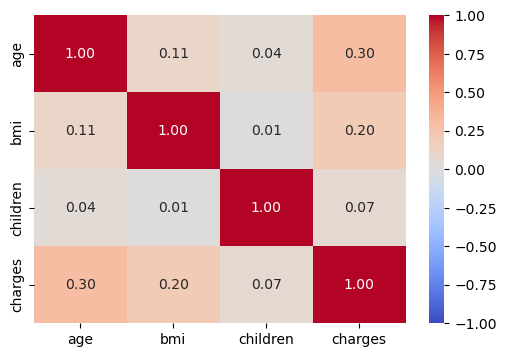

In [70]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.show()

In [71]:
cdf = df[['age','bmi','children','charges']]
cdf.head()

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520


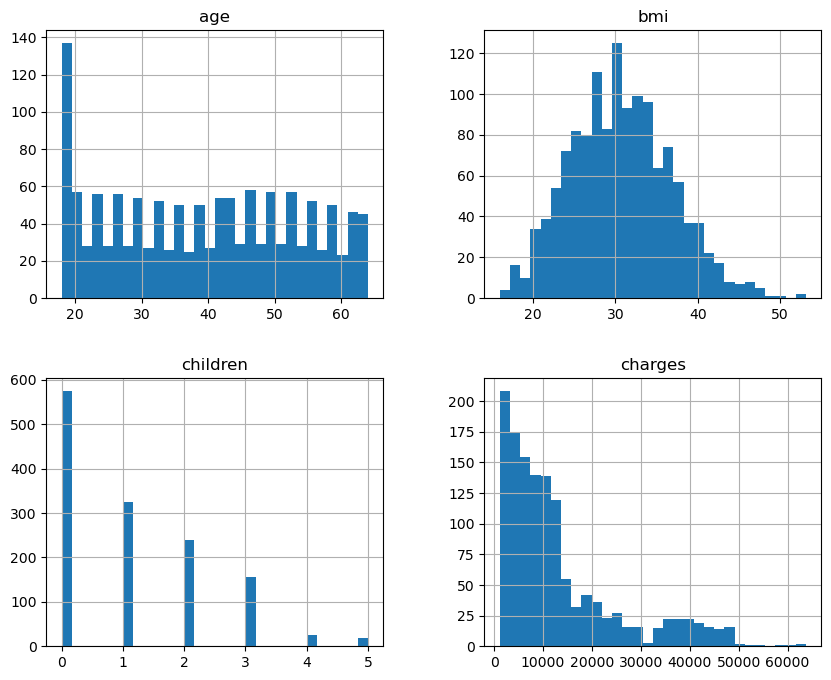

In [72]:
df[['age','bmi','children','charges']].hist(bins=30, figsize=(10,8))
plt.show()

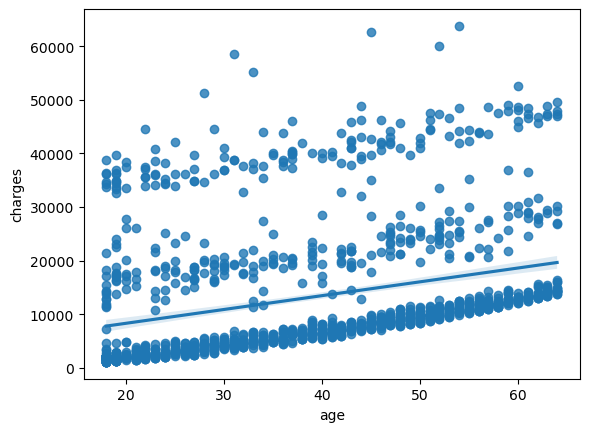

In [73]:
sns.regplot(x='age', y='charges', data=cdf)
plt.show()

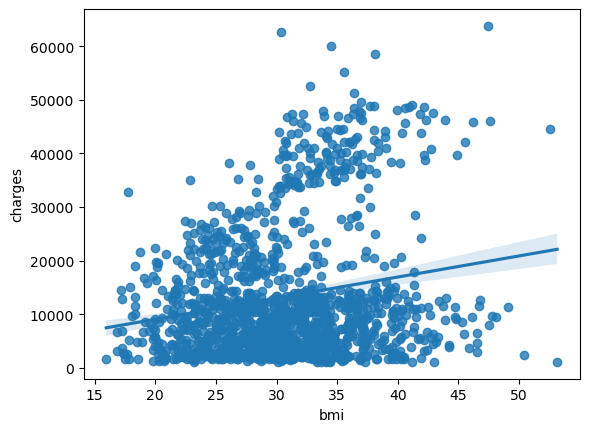

In [74]:
sns.regplot(x='bmi', y='charges', data=cdf)
plt.show()

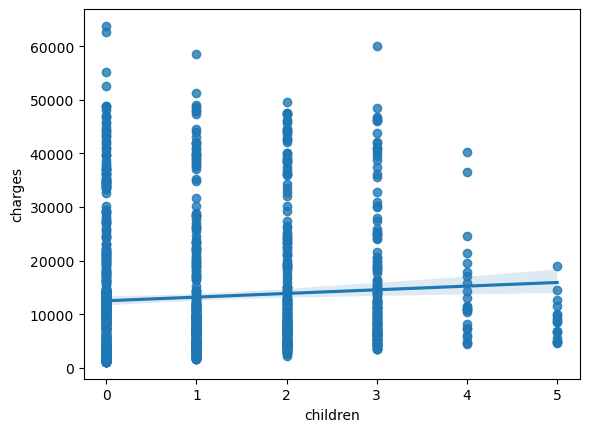

In [75]:
sns.regplot(x='children', y='charges', data=cdf)
plt.show()

# PARTE 1: Modelo de regresión simple una sola variable predictora 
- Usar la variable **age** como variable predictora y la variable de salida es **charges**

### 3. Seleccionando variable independiente y dependiente y separando datos en entrenamiento y prueba


In [76]:
from sklearn.model_selection import train_test_split

# Definición de variables predictoras y variable objetivo
X = cdf[['age']]
y = cdf['charges']

# División de los datos en conjunto de entrenamiento y conjunto de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imprimir tamaños de los conjuntos de entrenamiento y prueba

print("------- Train Data -------")
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de y_train:", y_train.shape)

print("------- Test Data -------")
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_test:", y_test.shape)

------- Train Data -------
Tamaño de X_train: (1070, 1)
Tamaño de y_train: (1070,)
------- Test Data -------
Tamaño de X_test: (268, 1)
Tamaño de y_test: (268,)


4.- Aplicando regresión simple, mostrando los coeficientes y escribiendo la ecuación

In [77]:
from sklearn.linear_model import LinearRegression

# El modelo 'lm' de regresión lineal se ajusta a los datos de entrenamiento
lm = LinearRegression()

lm.fit(X_train, y_train) 

print("Coeficiente:", lm.coef_)
print("Intercepción:", lm.intercept_)

Coeficiente: [240.59655979]
Intercepción: 3876.928684191711


$$ \hat{y} = 3876.93 + 240.60x $$

Donde $x$ es la edad (`age`). Por cada año adicional de edad, el costo del seguro aumenta en promedio unos $ 240.60

4.-Calculando valores predichos, errores, graficando la ecuación y los residuos de los datos de entrenamiento

### Graficamos el modelo

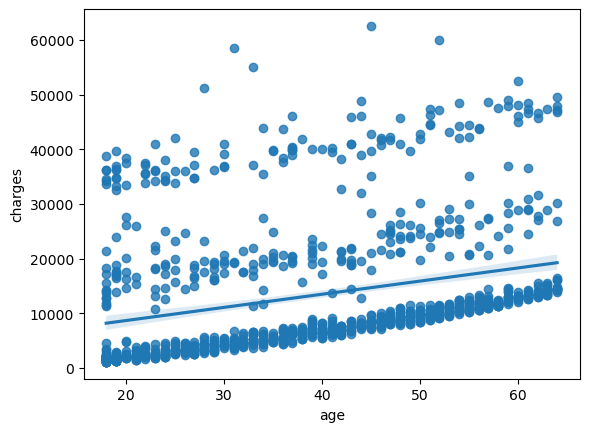

In [78]:
# Predicción de los valores de y para el conjunto de prueba
df_train = pd.concat([X_train, y_train], axis=1)

# Evaluación del modelo
sns.regplot(x="age", y="charges", data=df_train, fit_reg=True)
plt.show()

### Graficamos los residuales

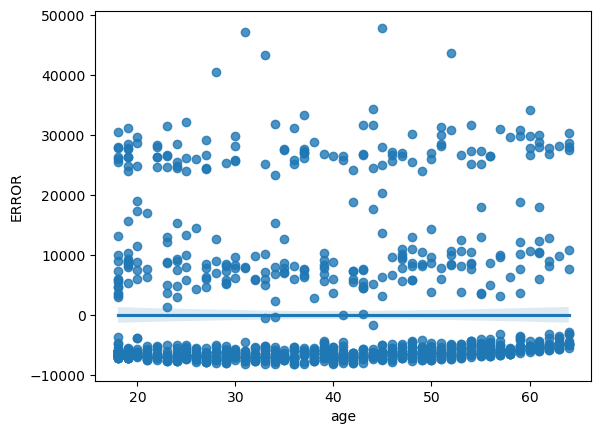

In [79]:
# Evaluación del modelo
df_train["ERROR"] = y_train - lm.predict(X_train)

# Visualización de los errores del modelo
sns.regplot(x="age", y="ERROR", data=df_train, fit_reg=True)
plt.show()

### 5.- Calculando valores predichos, errores, graficando la ecuación y los residuos de los datos de prueba

**Graficamos el modelo (con los datos de prueba)**

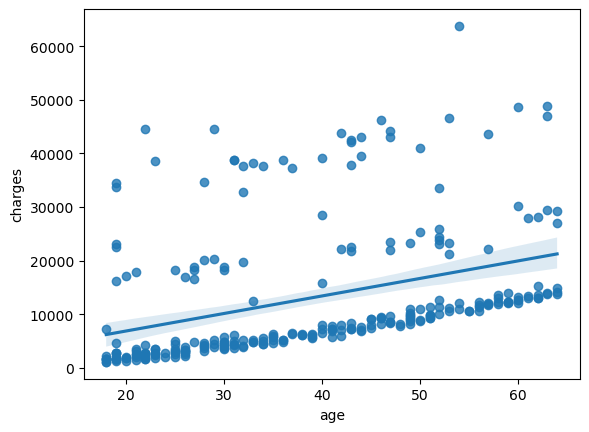

In [80]:
# Predicción de los valores de y para el conjunto de prueba
df_test = pd.concat([X_test, y_test], axis=1)

# Evaluación del modelo
sns.regplot(x="age", y="charges", data=df_test, fit_reg=True)
plt.show()

**Graficamos los residuales (con los datos de prueba)**

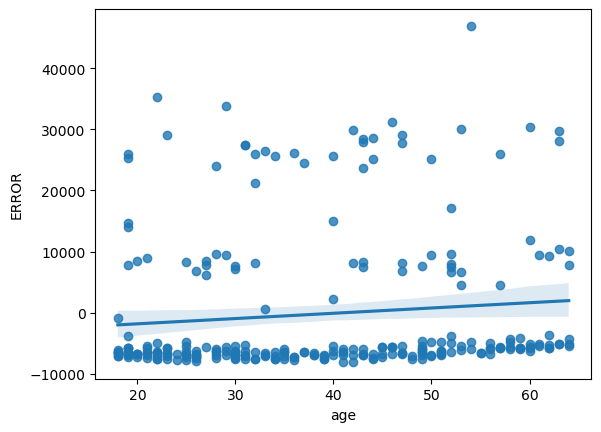

In [81]:
# validación del modelo
df_test["ERROR"] = y_test - lm.predict(X_test)

# Visualización de los errores del modelo
sns.regplot(x="age", y="ERROR", data=df_test, fit_reg=True)
plt.show()

### 6.- Calculando MSE y R2 para modelo de regresion simple en los datos de entrenamiento y prueba

In [82]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_train_hat = lm.predict(X_train)
print("MAE train:", mean_absolute_error(y_train, y_train_hat))
print("MSE train:", mean_squared_error(y_train, y_train_hat))
print("R2 train:", r2_score(y_train, y_train_hat))

print("\n")
y_test_hat = lm.predict(X_test)
print("MAE test:", mean_absolute_error(y_test, y_test_hat))
print("MSE test:", mean_squared_error(y_test, y_test_hat))
print("R2 test:", r2_score(y_test, y_test_hat))

MAE train: 9042.420854335864
MSE train: 132878350.42028472
R2 train: 0.07936661852890314


MAE test: 9173.25819674659
MSE test: 135983957.48054692
R2 test: 0.12408973539501933


El R2 es bajo, 0.12. La edad por si sola no puede explicar todo el costo